   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


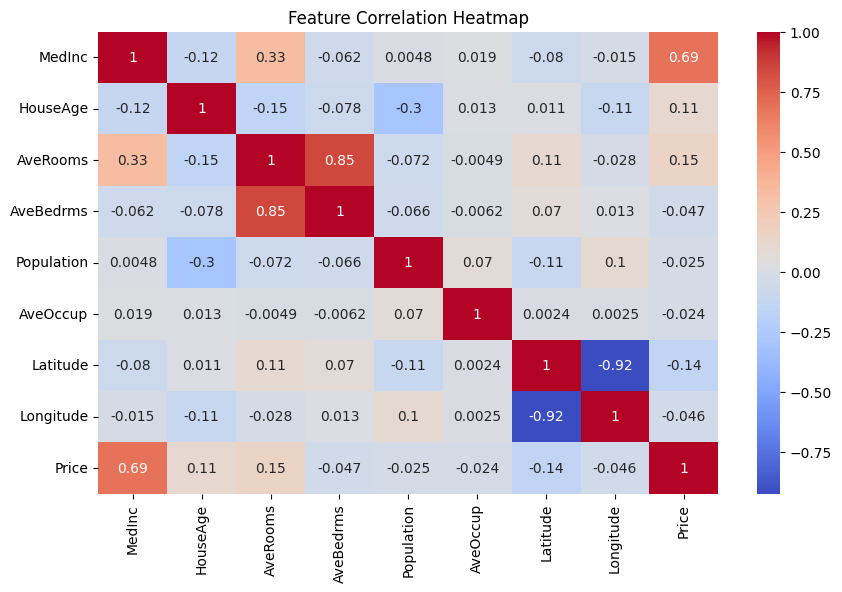

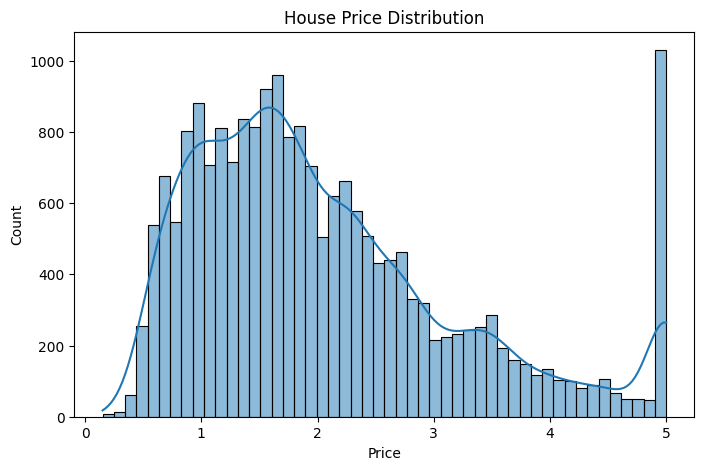

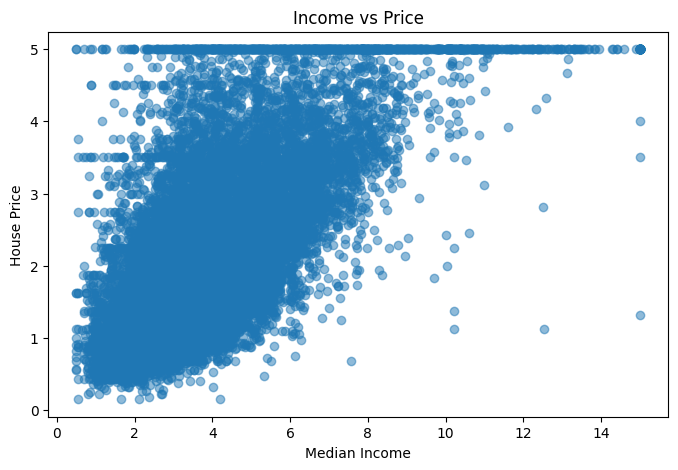

MSE: 0.5558915986952444
R2 Score: 0.5757877060324508


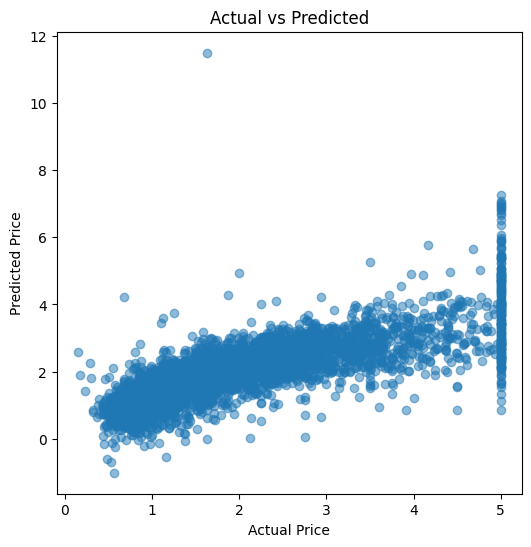


Enter values to predict house price:

Median Income: 40
House Age: 4
Average Rooms: 3
Average Bedrooms: 2
Population: 7
Average Occupancy: 10
Latitude: 23
Longitude: 32

🏠 Predicted House Price: -41.41022716685701


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [2]:
# 🔹 IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 LOAD DATASET
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print(df.head())

# 🔹 DATA VISUALIZATION

# 1. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# 2. Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title("House Price Distribution")
plt.show()

# 3. Income vs Price
plt.figure(figsize=(8,5))
plt.scatter(df['MedInc'], df['Price'], alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Income vs Price")
plt.show()

# 🔹 TRAIN MODEL
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# 🔹 EVALUATION
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# 🔹 ACTUAL VS PREDICTED
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()


# 🔥 USER INPUT PREDICTION SYSTEM

print("\nEnter values to predict house price:\n")

MedInc = float(input("Median Income: "))
HouseAge = float(input("House Age: "))
AveRooms = float(input("Average Rooms: "))
AveBedrms = float(input("Average Bedrooms: "))
Population = float(input("Population: "))
AveOccup = float(input("Average Occupancy: "))
Latitude = float(input("Latitude: "))
Longitude = float(input("Longitude: "))

# Create input array
user_data = np.array([[MedInc, HouseAge, AveRooms, AveBedrms,
                       Population, AveOccup, Latitude, Longitude]])

prediction = model.predict(user_data)

print("\n🏠 Predicted House Price:", prediction[0])